In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

import os

from docutils.nodes import container
from matplotlib.pyplot import bar_label
'''

# List of CSV files and their corresponding table names
csv_files = [
    ('ola.csv', 'ola'),
   # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rajput@1412',
    database='oladdb'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/data science/data analysis/ola'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)

    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()
'''


'\n\n# List of CSV files and their corresponding table names\ncsv_files = [\n    (\'ola.csv\', \'ola\'),\n   # Added payments.csv for specific handling\n]\n\n# Connect to the MySQL database\nconn = mysql.connector.connect(\n    host=\'localhost\',\n    user=\'root\',\n    password=\'Rajput@1412\',\n    database=\'oladdb\'\n)\ncursor = conn.cursor()\n\n# Folder containing the CSV files\nfolder_path = \'D:/data science/data analysis/ola\'\n\ndef get_sql_type(dtype):\n    if pd.api.types.is_integer_dtype(dtype):\n        return \'INT\'\n    elif pd.api.types.is_float_dtype(dtype):\n        return \'FLOAT\'\n    elif pd.api.types.is_bool_dtype(dtype):\n        return \'BOOLEAN\'\n    elif pd.api.types.is_datetime64_any_dtype(dtype):\n        return \'DATETIME\'\n    else:\n        return \'TEXT\'\n\nfor csv_file, table_name in csv_files:\n    file_path = os.path.join(folder_path, csv_file)\n\n    # Read the CSV file into a pandas DataFrame\n    df = pd.read_csv(file_path)\n\n    # Replace 

In [5]:
db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rajput@1412',
    database='oladdb'
)

cur=db.cursor()


**QUESTION:1**  1. Retrieve all successful bookings:


In [6]:
query=""" select Customer_ID,Booking_ID,Booking_Status from ola where Booking_Status='Success'"""

cur.execute(query)
data=cur.fetchall()
data
df=pd.DataFrame(data)
df.columns=['Customer_ID','Booking_ID','Booking_Status']
df


,Customer_ID,Booking_ID,Booking_Status
0,CID225428,CNR2940424040,Success
1,CID270156,CNR2982357879,Success
2,CID939555,CNR1797421769,Success
3,CID802429,CNR8787177882,Success
4,CID476071,CNR3612067560,Success
...,...,...,...
127929,CID371654,CNR9488489435,Success
127930,CID334158,CNR3151743100,Success
127931,CID113188,CNR1286151233,Success
127932,CID118301,CNR2027162035,Success


**QUESTION:2** Find the average ride distance for each vehicle type

In [19]:
query="""select Vehicle_Type,sum(Ride_Distance),avg(Ride_Distance) from ola group by Vehicle_Type"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Vehicle_Type','Total_Ride_Distance','Average_Ride_Distance']
df


,Vehicle_Type,Total_Ride_Distance,Average_Ride_Distance
0,Prime Sedan,234535,15.7649
1,Bike,227746,15.5331
2,Prime SUV,223848,15.2745
3,eBike,230842,15.5806
4,Mini,225703,15.5101
5,Prime Plus,227186,15.4475
6,Auto,92043,6.2381


**QUESTION:3** Get The total number of cancelled rides by customers:

In [20]:
query="""select count(Booking_Status) as cancelled_rides from ola where Booking_Status = 'Canceled by Customer'"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Cancelled_Rides']
df

,Cancelled_Rides
0,10499


**QUESTION : 4**  List the top 5 customers who booked the highest number of rides:


In [22]:
query="""select Customer_ID,count(booking_id) from ola group by customer_id order by count(booking_id) desc limit 5"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Customer_ID','Total_Rides']
df

,Customer_ID,Total_Rides
0,CID954071,5
1,CID539191,4
2,CID189965,4
3,CID268274,4
4,CID952434,4


**QUESTION :5** Get the number of rides cancelled by drivers due to personal and car-related issues:


In [23]:
query="""SELECT
    Canceled_Rides_by_Driver,
    COUNT(Canceled_Rides_by_Driver) AS occurrence_count
FROM ola
GROUP BY Canceled_Rides_by_Driver
union all
SELECT
    'Total' AS Canceled_Rides_by_Driver,
    COUNT(*) AS occurrence_count
FROM ola;"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Canceled_Rides_by_Driver','occurrence_count']
df

,Canceled_Rides_by_Driver,occurrence_count
0,Personal & Car related issue,6542
1,None,0
2,Customer was coughing/sick,3654
3,Customer related issue,5413
4,More than permitted people in there,2825
5,Total,103024


**QUESTION:6** Find the maximum and minimum driver ratings for Prime Sedan bookings


In [8]:
query="""select max(Driver_Ratings),min(driver_ratings) from ola where Vehicle_Type='Prime Sedan' order by driver_ratings desc
"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Maximum_Driver_Ratings','Minimum_Driver_Ratings']
df

,Maximum_Driver_Ratings,Minimum_Driver_Ratings
0,5.0,3.0


**QUESTION:7**   Find the average customer rating per vehicle type:


<Axes: xlabel='Vehicle_Type', ylabel='Average_Customer_Rating'>

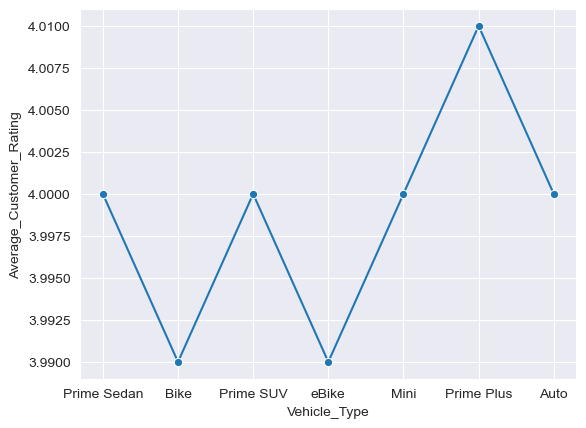

In [16]:
query=""" select Vehicle_Type,round(avg(Customer_Rating),2)from ola group by Vehicle_Type"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Vehicle_Type','Average_Customer_Rating']
sns.lineplot(x='Vehicle_Type',y='Average_Customer_Rating',data=df,marker='o')

**QUESTION:8**   Retrieve all rides where payment was made using UPI:


In [18]:
query=""" select customer_id,booking_id from ola where Payment_Method='UPI' group by customer_id,booking_id"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['cid','bid']
df

,cid,bid
0,CID270156,CNR2982357879
1,CID802429,CNR8787177882
2,CID540929,CNR4524472111
3,CID167642,CNR8181602032
4,CID640151,CNR8090918544
...,...,...
25876,CID266336,CNR4870774895
25877,CID922711,CNR9738039746
25878,CID334158,CNR3151743100
25879,CID118301,CNR2027162035


**QUESTION:9** Calculate the total booking value of rides completed successfully:


In [19]:
query="""select count(distinct(booking_id)) from ola where Booking_Status='Success' """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Total_Booking_Value']
df

,Total_Booking_Value
0,63967


**QUESTION:10** List all incomplete rides along with the reason:


In [20]:
query=""" select booking_id,Booking_Status from ola where Booking_Status!= 'Success' """

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['Booking_id','Booking_Status']
df




,Booking_id,Booking_Status
0,CNR7153255142,Canceled by Driver
1,CNR2395710036,Canceled by Customer
2,CNR5374902489,Canceled by Driver
3,CNR5030602354,Driver Not Found
4,CNR6328453219,Canceled by Driver
...,...,...
78109,CNR9936519920,Driver Not Found
78110,CNR2746062760,Canceled by Driver
78111,CNR8606968614,Driver Not Found
78112,CNR1504131542,Canceled by Driver
